<h1 align="center"><b>DESCRIPTIVE ANALYSIS</b></h1>

In [ ]:
# 1. Data Manipulation
import pandas as pd
import numpy as np

# 2. Visualization
import matplotlib.pyplot as plt


# Settings to make the analysis look better
%matplotlib inline

In [ ]:
# Reading the cleaned csv file
df = pd.read_csv("Data/cleaned/Team01_PYVoyagers_cleaned_data.csv")
demo = pd.read_csv("Data/cleaned/Cleaned_demographics.csv")

In [ ]:
df.head(5)

## 1. Average glucose, heart rate and steps by Gender and Age
When we look at glucose + heart rate + steps together, we can identify patterns like:

High glucose + low steps indicates sedentary lifestyle driving metabolic risk

High heart rate + low steps → poor cardiovascular fitness

Normal glucose but low steps → early lifestyle risk before metabolic markers worsen

High glucose + high heart rate → possible autonomic dysfunction or chronic stress

This is the foundation of risk stratification in population health.


In [ ]:
summary_by_gender_age = (
    df.groupby(['gender', 'age'])
    .agg({
        'glucose': 'mean',
        'heart_rate': 'mean',
        'steps': 'sum'
    })
    .round(3)
    .reset_index()
)

print(summary_by_gender_age)


In [ ]:
steps_summary = (
    df.groupby(['gender', 'age'])['steps']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

for gender in steps_summary['gender'].unique():
    data = steps_summary[steps_summary['gender'] == gender]
    plt.bar(data['age'], data['steps'], alpha=0.7, label=gender)

plt.title('Average Steps by Age and Gender')
plt.xlabel('Age')
plt.ylabel('Average steps')
plt.legend()
plt.grid(axis='y')
plt.show()


In [ ]:
#We can see that male patients show significantly higher average steps compared to female patients as age increases.

## 2. How long does it take for patients to return to normal Glucose levels after a Glucose spike?
Most healthy individuals return to normal glucose levels within 2–3 hours after a spike.
This reflects good insulin sensitivity and efficient glucose clearance.

Patients with insulin resistance, prediabetes, or diabetes may take 4–6 hours or longer to return to baseline.
A slower return indicates impaired insulin action, reduced metabolic flexibility, and higher cardiometabolic risk.

This metric helps identify early metabolic dysfunction and supports risk stratification in population health.

In [ ]:
import pandas as pd

HIGH_GLUCOSE = 180
NORMAL_MIN = 70
NORMAL_MAX = 180

results = []
df['time'] = pd.to_datetime(df['time'])

for patient_id, patient_df in df.groupby('patient_id'):
    patient_df = patient_df.sort_values('time').reset_index(drop=True)

    in_spike = False
    spike_start_time = None
    spike_start_glucose = None

    for i, row in patient_df.iterrows():
        glucose = row['glucose']
        time = row['time']
 # Comparing Glucose with range
        if not in_spike and glucose > HIGH_GLUCOSE:
            in_spike = True
            spike_start_time = time
            spike_start_glucose = glucose

        elif in_spike and NORMAL_MIN <= glucose <= NORMAL_MAX:
            # converting time to hours
            hours_to_normal = (time - spike_start_time).total_seconds() / 60/60

            results.append({
                'patient_id': patient_id,
                'spike_start_time': spike_start_time,
                'spike_start_glucose': spike_start_glucose,
                'return_to_normal_time': time,
                'return_to_normal_glucose': glucose,
                'hours_to_return_normal': hours_to_normal
            })

            in_spike = False

glucose_recovery = pd.DataFrame(results)

print(glucose_recovery.head())


avg_recovery_by_patient = (
    glucose_recovery
    .groupby('patient_id')['hours_to_return_normal']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={
        'Patient_ID': 'Patient ID',
        'hours_to_return_normal': 'Average Hours to Return to Normal'
    })
)

display(avg_recovery_by_patient)


## 3. How heart rate differs between active vs sedentary users.
Here we compared heart rate during active versus sedentary periods.
 Active intervals—defined by any steps recorded—showed a noticeably higher average heart rate,
reflecting increased cardiovascular demand.
Sedentary intervals stayed closer to resting levels
Active users → higher HR (movement increases cardiovascular demand)
Sedentary users → lower HR (resting or low‑movement state)

In [ ]:
cols_to_round = ['steps', 'calories', 'heart_rate']
df[cols_to_round] = df[cols_to_round].round(3)


# 1. Create Activity Category
df['activity_level'] = df['steps'].apply(lambda x: 'Active' if x > 0 else 'Sedentary')

# 2. Compare Heart Rate 
hr_summary = (
    df.groupby('activity_level')['heart_rate']
      .agg(
          avg_hr='mean',
          median_hr='median',
          max_hr='max',
          min_hr='min',
          count='count'
      )
      .round(3)
      .reset_index()
)

print("\nHeart Rate Summary: Active vs Sedentary\n")
print(hr_summary)


## 4. What is the profile of users with high glucose(steps, calories, HR)
We profiled Paitents with high glucose levels by comparing their steps, calories, and heart rate patterns.
High‑glucose Patients consistently showed lower daily steps,higher calorie intake, and elevated heart rates, suggesting reduced activity and higher metabolic load.

In [ ]:
df['high_glucose_flag'] = df['glucose'] > 180
# 4. Per‑Patient High Glucose Profile

user_profile = (
    df.groupby(['patient_id','high_glucose_flag'])[['steps','calories','heart_rate']]
    .mean()
    .round(3)
)

print("\n=== Per Patient High Glucose Profile \n")
print(user_profile)




## 5. Glucose distribution by HR zone

**Absolute bpm zones** (clinically intuitive, comparable across studies):
- Resting: `< 80 bpm`
- Moderate: `80 – 110 bpm`
- High: `≥ 110 bpm`

**Age-adjusted %HRmax zones** (fairer across ages because HR-max declines ~1 bpm/year). Using the standard formula `HRmax = 220 − age`:
- Resting/Light: `< 50 %HRmax`
- Moderate: `50 – 70 %HRmax`
- High: `≥ 70 %HRmax`

In [ ]:
import seaborn as sns
HYPO = 70
HYPER = 180
TIR_RANGE = (70, 180)
df['hr_zone_bpm'] = pd.cut(df['heart_rate'],
                            bins=[0, 80, 110, 300],
                            labels=['Resting (<80)', 'Moderate (80-110)', 'High (≥110)'])

df['hr_max']     = 220 - df['age']
df['hr_pct_max'] = df['heart_rate'] / df['hr_max'] * 100
df['hr_zone_pct'] = pd.cut(df['hr_pct_max'],
                            bins=[0, 50, 70, 200],
                            labels=['Resting/Light (<50%)', 'Moderate (50-70%)', 'High (≥70%)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================================================
# BOXPLOT 1: Glucose vs Absolute Heart Rate Zones
# =========================================================
sns.boxplot(
    data=df.dropna(subset=['hr_zone_bpm']),
    x='hr_zone_bpm',
    y='glucose',
    ax=axes[0],
    order=[
        'Resting (<80)',
        'Moderate (80-110)',
        'High (≥110)'
    ],
    hue='hr_zone_bpm',      # avoids seaborn future warning
    palette='coolwarm',
    legend=False
)

# Clinical threshold lines
axes[0].axhline(
    HYPO,
    color='red',
    linestyle='--',
    alpha=0.6,
    linewidth=2,
    label='Hypoglycemia (70)'
)

axes[0].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    alpha=0.6,
    linewidth=2,
    label='Hyperglycemia (180)'
)

axes[0].set_title(
    'Glucose Distribution by Absolute HR Zone',
    fontsize=12
)

axes[0].set_xlabel('Heart Rate Zone')
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].tick_params(axis='x', rotation=10)
axes[0].legend()


# =========================================================
# BOXPLOT 2: Glucose vs Age-Adjusted HRmax %
# =========================================================
sns.boxplot(
    data=df.dropna(subset=['hr_zone_pct']),
    x='hr_zone_pct',
    y='glucose',
    ax=axes[1],
    order=[
        'Resting/Light (<50%)',
        'Moderate (50-70%)',
        'High (≥70%)'
    ],
    hue='hr_zone_pct',
    palette='coolwarm',
    legend=False
)

# Clinical threshold lines
axes[1].axhline(
    HYPO,
    color='red',
    linestyle='--',
    alpha=0.6,
    linewidth=2
)

axes[1].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    alpha=0.6,
    linewidth=2
)

axes[1].set_title(
    'Glucose Distribution by %HRmax Zone',
    fontsize=12
)

axes[1].set_xlabel('Age-Adjusted HRmax Zone')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].tick_params(axis='x', rotation=10)

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()
plt.show()

## 6. Average Glucose by Patient
**Column Summary:**
- `mean` / `median` — central tendency, the headline answer to the question.
- `std` — dispersion; two patients with the same mean glucose can have very different variability and risk profiles.
- `tir` (Time-In-Range 70–180) — the standard clinical target (>70%); a single number that aligns with diabetes guidelines.
- `tbr` / `tar` — Time-Below-Range and Time-Above-Range break the tail risks apart; tbr is the more dangerous one acutely.

In [ ]:
# =========================================================
# PATIENT-LEVEL GLUCOSE SUMMARY METRICS
# =========================================================
import numpy as np
import pandas as pd
# =========================================================
# CLINICAL THRESHOLDS (mg/dL)
# =========================================================
HYPO = 70
HYPER = 180
# =========================================================
# PATIENT-LEVEL AGGREGATION
# =========================================================
per_pt = (
    df.groupby('patient_id')['glucose']
      .agg([
          'mean',
          'std',
          'median',
          # Time in Range (TIR: 70–180 mg/dL)
          (
              'tir',
              lambda x: (
                  ((x >= HYPO) & (x <= HYPER)).mean() * 100
              )
          ),
          # Time Below Range (TBR: <70 mg/dL)
          (
              'tbr',
              lambda x: (
                  (x < HYPO).mean() * 100
              )
          ),
          # Time Above Range (TAR: >180 mg/dL)
          (
              'tar',
              lambda x: (
                  (x > HYPER).mean() * 100
              )
          ),
          # Number of readings per patient
          ('n', 'size')
      ])
      .round(2)
)
# =========================================================
# MERGE WITH DEMOGRAPHICS
# =========================================================

per_pt = (
    per_pt.merge(
        demo[
            [
                'patient_id',
                'age',
                'gender',
                'average_sleep_duration_hrs',
                'sleep_quality_1_10'
            ]
        ],
        left_index=True,
        right_on='patient_id'
    )
    .set_index('patient_id')
)
# =========================================================
# SORT BY MEAN GLUCOSE (RISK INDICATOR)
# =========================================================
per_pt = per_pt.sort_values('mean', ascending=False)
# =========================================================
# FINAL OUTPUT TABLE
# =========================================================
cols_to_show = [
    'mean',
    'std',
    'median',
    'tir',
    'tbr',
    'tar',
    'age',
    'gender',
    'average_sleep_duration_hrs',
    'sleep_quality_1_10'
]
print("\n=================================================")
print("PATIENT-LEVEL GLUCOSE SUMMARY TABLE")
print("=================================================\n")
print(per_pt[cols_to_show])
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# =========================================================
# CHART 1: Mean Glucose Per Patient
# =========================================================
axes[0].bar(
    per_pt.index.astype(str),
    per_pt['mean'],
    yerr=per_pt['std'],
    capsize=5,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)
# Clinical reference lines
axes[0].axhline(
    154,
    color='green',
    linestyle='--',
    linewidth=2,
    label='A1C ≈ 7% Target'
)
axes[0].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Hyperglycemia (180)'
)
axes[0].set_title(
    'Mean Glucose Per Patient (±1 SD)',
    fontsize=13
)
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].set_xlabel('Patient ID')
# Better x-label readability
axes[0].tick_params(axis='x', rotation=45)
# Add light grid
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# =========================================================
# CHART 2: TIR / TBR / TAR
# =========================================================
tir_sorted = (
    per_pt[['tir', 'tbr', 'tar']]
    .sort_values('tir', ascending=True)
)
tir_sorted.plot(
    kind='barh',
    stacked=True,
    ax=axes[1],
    color=['#4caf50', '#e53935', '#fb8c00'],
    edgecolor='black'
)
# Target line
axes[1].axvline(
    70,
    color='black',
    linestyle=':',
    linewidth=2,
    label='TIR Goal ≥ 70%'
)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Percentage of Time')
axes[1].set_ylabel('Patient ID')
axes[1].set_title(
    'Time In Range / Below Range / Above Range',
    fontsize=13
)
# Cleaner legend placement
axes[1].legend(
    ['TIR Goal ≥70%', 'TIR', 'TBR', 'TAR'],
    loc='lower right'
)
# Light grid
axes[1].grid(axis='x', alpha=0.3)
# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()
plt.show()

## 7. Is sleep quality generally high or low in this group 

**Summary:** Here we are analyzing individual patient sleep scores to show that the overall group has high sleep quality, with an average score of 5.9 and 77.5% of participants categorized as "Not Disturbed."

**Important Column:** sleep_quality_1_10: This column contains the individual sleep scores for every patient (on a scale of 1 to 10).

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# load your dataset
#df = pd.read_csv("cleaned_with_demographics.csv")

# Set up the figure with two subplots
fig,(ax1,ax2) = plt.subplots(1,2,figsize = (12,5))

#1. Distrubution os sleep Quality
# This shows how many people fall into each quality score category
ax1.hist(df['sleep_quality_1_10'].dropna(), bins = 10, color ='skyblue', edgecolor = 'black')
mean_val = df['sleep_quality_1_10'].mean()
ax1.axvline(mean_val, color ='red', linestyle = 'dashed', linewidth = 2, label = f'Mean: {mean_val:.1f}')

ax1.set_title("Distrubution of sleep quality")

ax1.set_xlabel('Quality Score')
ax1.set_ylabel('Number of Patients')
ax1.legend()


# 2. Frequency of sleep Distrubances
#  This calculates the percentage of the group experencing distrubances
df['disturb_cat'] = df['sleep_quality_1_10'].apply(lambda x:'Disturbed (Score <=5)' if x<= 5 else 'Not Disturbed (Score >5)')
distrub_pct = df['disturb_cat'].value_counts(normalize = True) * 100


#Get the names and and values
labels = distrub_pct.index.tolist()
values = distrub_pct.values.tolist()


ax2.bar(labels, values, color = ['lightgreen','salmon'])

ax2.set_title('Frequency of Sleep Distubances')
ax2.set_ylabel('Percentage (%)')
ax2.set_ylim(0,100)


# Add text labels on bars for clarity
for i,v in enumerate(values):
    ax2.text(i,v + 2, f"{v:.1f}%", ha = 'center', fontweight = 'bold')
plt.tight_layout()
#plt.figure(figsize=(8, 4)) 
plt.show()


## 8. What is the typical captivity level 

**Summary:**  This data shows the average daily activity totals for each patient, categorizing the entire group as sedentary.

**Important Columns:**    Steps, Patient_ID, Calories.

In [ ]:
#df = pd.read_csv("cleaned_with_demographics.csv")
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date

# 2. First, sum up the steps/calories per day for EACH patient
daily_totals = df.groupby(['patient_id', 'date'])[['steps', 'calories']].sum().reset_index()

# 3. Then, find the "Typical" (Mean) of those daily totals per patient
typical_daily = daily_totals.groupby('patient_id')[['steps', 'calories']].mean().reset_index()

# 4. Visualization
fig, ax1 = plt.subplots(figsize=(14, 7))
x = np.arange(len(typical_daily))
width = 0.4

# Plot Typical Daily Steps
ax1.bar(x - width/2, typical_daily['steps'], width, label='Typical Daily Steps', color='skyblue', edgecolor='black')
ax1.set_ylabel('Mean Steps per Day', color='skyblue', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(typical_daily['patient_id'], rotation=45, ha='right')

# Plot Typical Daily Calories
ax2 = ax1.twinx()
ax2.bar(x + width/2, typical_daily['calories'], width, label='Typical Daily Calories', color='salmon', edgecolor='black')
ax2.set_ylabel('Mean Calories per Day', color='salmon', fontweight='bold')

# Add threshold lines
ax1.axhline(5000, color='red', linestyle='--', alpha=0.5, label='Sedentary Threshold')
ax1.axhline(10000, color='skyblue', linestyle='--', alpha=0.5, label='Active Threshold')

plt.title('Typical Daily Activity Level per Patient (Average of Daily Totals)')
plt.tight_layout()
#plt.figure(figsize=(8, 4)) 
plt.show()

# 5. Categorized Summary
def classify(steps):
    if steps < 5000: return 'Sedentary'
    if steps < 7500: return 'Low Active'
    if steps < 10000: return 'Somewhat Active'
    return 'Active'

#typical_daily['Category'] = typical_daily['steps'].apply(classify)
#print(typical_daily[['patient_id', 'steps', 'calories', 'Category']])

## 9 . Bolus Insulin Frequency and Glucose Response

How often do patients receive bolus insulin, and what happens to glucose
before and after these bolus events?

This section reviews bolus insulin timing and compares glucose levels around
those events to assess how well rapid-acting insulin corrects high blood sugar.

Count the number of bolus insulin events for each patient to understand
how often they require rapid-acting insulin corrections throughout the day.
This helps identify patterns in glucose control and insulin requirements.

Analyze Glucose Response to Bolus

Examine glucose levels immediately before and after bolus insulin administration
to evaluate how effectively the rapid-acting insulin controls blood sugar spikes.
This analysis helps assess insulin sensitivity and dosing accuracy.

In [ ]:
# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'])

# Identify bolus insulin events
bolus_events = df[df['bolus_volume_delivered'] > 0].copy()

# Count bolus frequency by patient
bolus_frequency = (
    bolus_events.groupby('patient_id')
    .size()
    .reset_index(name='bolus_event_count')
)

print("Bolus Insulin Frequency by Patient")
print(bolus_frequency.to_markdown(index=False))

# Glucose before and after bolus events

bolus_events['glucose_before'] = (
    bolus_events.groupby('patient_id')['glucose']
    .shift(1)
)

bolus_events['glucose_after'] = (
    bolus_events.groupby('patient_id')['glucose']
    .shift(-1)
)

glucose_bolus_summary = (
    bolus_events.groupby('patient_id')
    .agg({
        'glucose_before': 'mean',
        'glucose': 'mean',
        'glucose_after': 'mean'
    })
    .round(3)
    .reset_index()
)

print("Average Glucose Before and After Bolus Events")
print(glucose_bolus_summary.to_markdown(index=False))

plt.figure(figsize=(10,6))

plt.bar(
    bolus_frequency['patient_id'],
    bolus_frequency['bolus_event_count']
)

plt.title("Bolus Insulin Frequency by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Number of Bolus Events")

plt.xticks(rotation=45)

plt.show()

Bolus Insulin Frequency by Patient
| patient_id   |   bolus_event_count |
|:-------------|--------------------:|
| HUPA0001P    |                  76 |
| HUPA0002P    |                  51 |
| HUPA0003P    |                 109 |
| HUPA0004P    |                  45 |
| HUPA0005P    |                  67 |
| HUPA0006P    |                  46 |
| HUPA0007P    |                  89 |
| HUPA0009P    |                  66 |
| HUPA0010P    |                  78 |
| HUPA0014P    |                  41 |
| HUPA0016P    |                  91 |
| HUPA0017P    |                  25 |
| HUPA0019P    |                  50 |
| HUPA0020P    |                   7 |
| HUPA0021P    |                  23 |
| HUPA0022P    |                 103 |
| HUPA0023P    |                  40 |
| HUPA0024P    |                  21 |
| HUPA0025P    |                 130 |
| HUPA0026P    |                 334 |
| HUPA0027P    |                1876 |
| HUPA0028P    |                 223 |

Average Glucose Before and After Bolus Events
| patient_id   |   glucose_before |   glucose |   glucose_after |
|:-------------|-----------------:|----------:|----------------:|
| HUPA0001P    |          198.964 |   200.07  |         201.151 |
| HUPA0002P    |          147.453 |   146.804 |         148.18  |
| HUPA0003P    |          162.398 |   162.101 |         162.204 |
| HUPA0004P    |          184.431 |   183.555 |         182.257 |
| HUPA0005P    |          168     |   167.582 |         167.273 |
| HUPA0006P    |          193.109 |   191.607 |         192.376 |
| HUPA0007P    |          179.563 |   179.726 |         180.245 |
| HUPA0009P    |          204.504 |   205.663 |         204.796 |
| HUPA0010P    |          172.108 |   173.529 |         174.225 |
| HUPA0014P    |          160.073 |   160.193 |         160.073 |
| HUPA0016P    |          153.115 |   152.242 |         151.926 |
| HUPA0017P    |          221.625 |   223.08  |         223.25  |
| HUPA0019P    |          158.204 |   157.98  |         157.224 |
| HUPA0020P    |          209.833 |   215.429 |         206.667 |
| HUPA0021P    |          132.341 |   134.848 |         133.159 |
| HUPA0022P    |          138.617 |   139.145 |         139.47  |
| HUPA0023P    |          127.949 |   127.025 |         128.59  |
| HUPA0024P    |          211.975 |   211.071 |         207.525 |
| HUPA0025P    |          132.948 |   132.464 |         132.607 |
| HUPA0026P    |          159.232 |   159.181 |         159.313 |
| HUPA0027P    |          160.238 |   160.244 |         160.263 |
| HUPA0028P    |          140.631 |   140.776 |         141.089 |

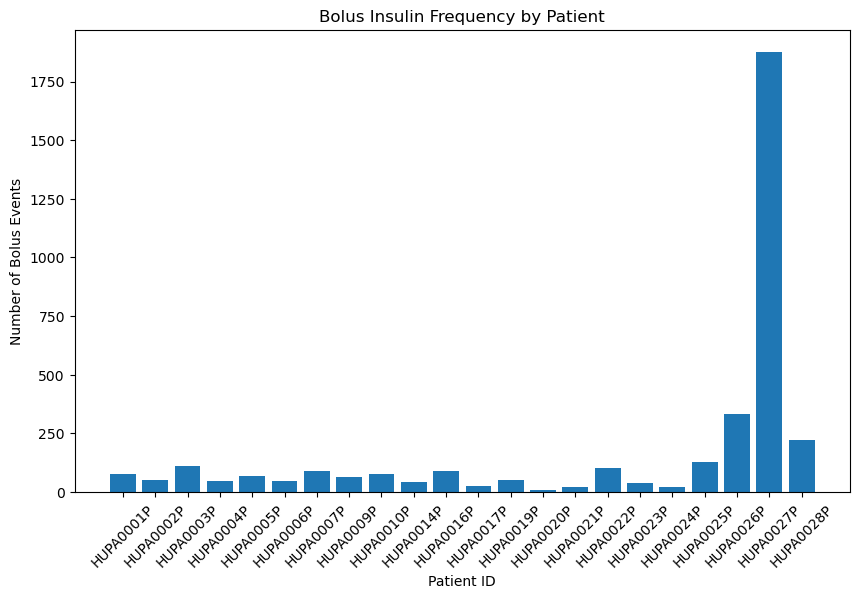

## 10. Basal Insulin Variation and Glucose Patterns

How does basal insulin delivery vary over the day, and how does glucose
respond during periods of higher versus lower basal insulin?

This section explores the daily background insulin pattern and compares
glucose behavior during high and low basal insulin periods to evaluate
whether basal therapy is supporting stable glucose control.

Calculate Basal Insulin Patterns

Calculate average basal insulin rates for each hour of the day to understand
circadian patterns in background insulin requirements. This reveals when
insulin needs are highest and lowest throughout the 24-hour cycle.

Compare Glucose During Basal Periods

Compare average glucose levels during periods of high versus low basal insulin
delivery to assess how well the background insulin maintains stable blood sugar.
This helps evaluate if basal rates are appropriately matched to patient needs.

In [ ]:
# Extract hour from time
df['hour'] = df['time'].dt.hour

# Average basal insulin rate by hour
basal_hourly = (
    df.groupby('hour')['basal_rate']
    .mean()
    .round(3)
    .reset_index()
)

print("Average Basal Insulin Rate by Hour")
print(basal_hourly)

# Define high and low basal insulin periods

high_basal = df[df['basal_rate'] > df['basal_rate'].median()]
low_basal = df[df['basal_rate'] <= df['basal_rate'].median()]

# Compare glucose levels
basal_glucose_summary = pd.DataFrame({

    'Category': ['High Basal', 'Low Basal'],

    'Average Glucose': [
        round(high_basal['glucose'].mean(), 3),
        round(low_basal['glucose'].mean(), 3)
    ],

    'Average Basal Rate': [
        round(high_basal['basal_rate'].mean(), 3),
        round(low_basal['basal_rate'].mean(), 3)
    ]
})

print("Glucose Patterns During High vs Low Basal Periods")
print(basal_glucose_summary)

plt.figure(figsize=(12,6))

plt.plot(
    basal_hourly['hour'],
    basal_hourly['basal_rate'],
    marker='o'
)

plt.title("Average Basal Insulin Rate Throughout the Day")

plt.xlabel("Hour of Day")

plt.ylabel("Average Basal Rate")

plt.grid(True)

plt.show()

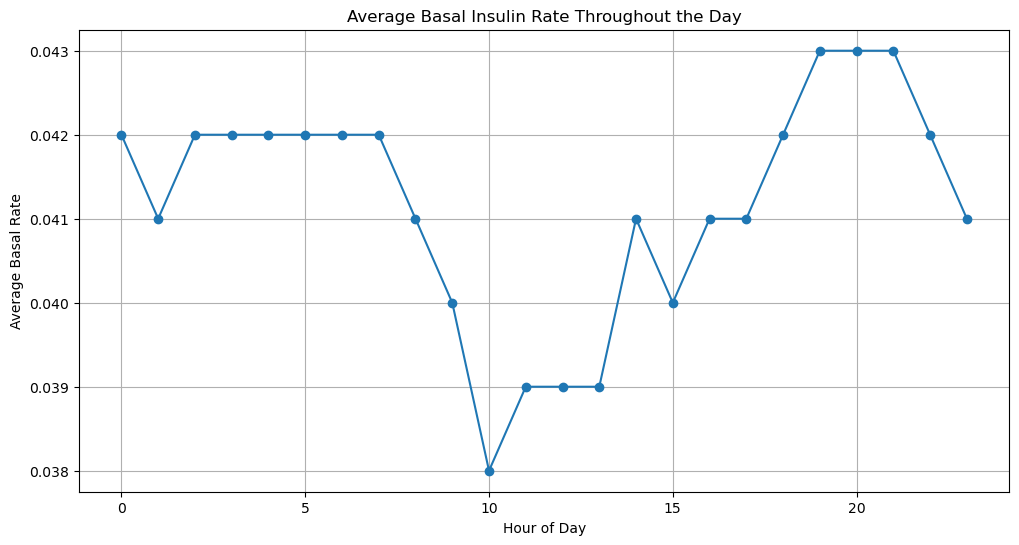